<a href="https://colab.research.google.com/github/Harnoor-13/Inflation-Research-Project/blob/main/weighted_average_stacking_ensemble_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

🚀 Initializing Phase 2: CNN-BiLSTM Architecture...

✔ Historical Training Data Shape: (157, 5)
✔ Training Sequences: 133, Testing Sequences: 12
✔ Input Tensor Shape: (133, 12, 5) (Samples, Time Steps, Features)



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 11, 64)         │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 200)            │       132,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,805 (557.83 KB)

 Trainable params: 142,805 (557.83 KB)

 Non-trainable params: 0 (0.00 B)

None

🚀 Training CNN-BiLSTM Model...
Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0618 - mae: 0.1970 - val_loss: 0.0081 - val_mae: 0.0892
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0065 - mae: 0.0650 - val_loss: 3.8243e-04 - val_mae: 0.0187
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0050 - mae: 0.0525 - val_loss: 5.4940e-04 - val_mae: 0.0226
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0029 - mae: 0.0398 - val_loss: 3.0146e-04 - val_mae: 0.0164
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0022 - mae: 0.0385 - val_loss: 0.0035 - val_mae: 0.0592
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0022 - mae: 0.0360 - val_loss: 5.0872e-05 - val_mae: 0.0056
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0018 - mae: 0.0318 - val_loss: 0.0026 - val_mae: 0.0508
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0014 - mae: 0.0283 - val_loss: 0.0029 - val_mae: 0.0534
Epoch 9/100
9/9 ━━━

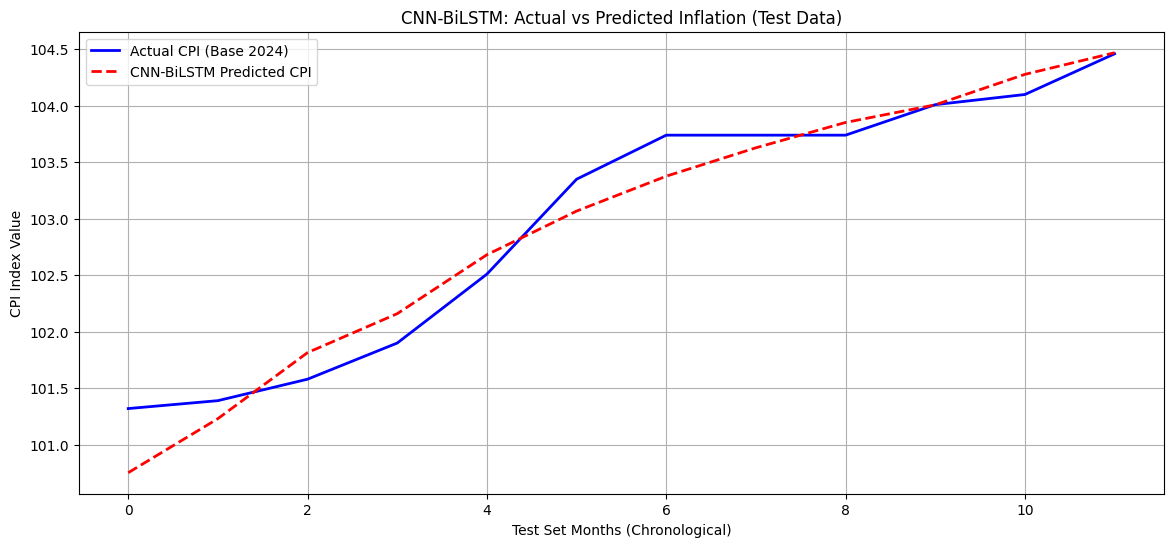


🏁 Model Training & Evaluation Complete!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Conv1D, MaxPooling1D, Dropout, Flatten
from tensorflow.keras.callbacks import EarlyStopping

print(" Initializing Phase 2: CNN-BiLSTM Architecture...\n")

# ==========================================
# 1. LOAD AND PREPARE DATA
# ==========================================
# Load the master dataset
df = pd.read_csv('Indian_Inflation_Master_Data_Base2024_Final.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# For TRAINING, we only use the historical data where CPI is known (Jan 2013 to Jan 2026)
# We will save the NaN future rows (Feb 2026 - Dec 2026) for our final predictions later!
historical_data = df.dropna(subset=['CPI']).copy()

# Define features and target
features = ['CPI', 'Brent_Oil', 'USD_INR', 'GDP', 'M3_Money_Supply']
data_values = historical_data[features].values

print(f" Historical Training Data Shape: {data_values.shape}")

# ==========================================
# 2. SCALING THE DATA
# ==========================================
# Neural networks require data to be scaled between 0 and 1.
# We keep a separate scaler for CPI so we can easily "inverse_transform" the predictions back to real numbers later.
feature_scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = feature_scaler.fit_transform(data_values)

cpi_scaler = MinMaxScaler(feature_range=(0, 1))
cpi_scaler.fit(historical_data[['CPI']])

# ==========================================
# 3. CREATING THE SLIDING WINDOW SEQUENCES
# ==========================================
def create_sequences(data, lookback_window):
    X, y = [], []
    # Slide the window across the dataset
    for i in range(lookback_window, len(data)):
        # X: The past 'lookback' months of ALL variables
        X.append(data[i-lookback_window:i, :])
        # y: The CPI (column index 0) of the current month
        y.append(data[i, 0])
    return np.array(X), np.array(y)

# We will use a 12-month lookback window (1 year of macro history to predict the next month)
LOOKBACK = 12
X, y = create_sequences(scaled_data, LOOKBACK)

# Hold out exactly the last 12 months for testing against MOSPI
test_months = 12
train_size = len(X) - test_months

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"✔ Training Sequences: {X_train.shape[0]}, Testing Sequences: {X_test.shape[0]}")
print(f"✔ Input Tensor Shape: {X_train.shape} (Samples, Time Steps, Features)\n")

# ==========================================
# 4. BUILDING THE CNN-BiLSTM ARCHITECTURE
# ==========================================
model = Sequential()

# CNN Layer: Extracts short-term spatial features and macroeconomic shocks
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))

# Bidirectional LSTM Layer: Learns long-term temporal dependencies forwards and backwards
model.add(Bidirectional(LSTM(100, return_sequences=False)))
model.add(Dropout(0.2)) # Prevents overfitting

# Output Layer: Predicts the single CPI value
model.add(Dense(50, activation='relu'))
model.add(Dense(1)) # Final prediction

model.compile(optimizer='adam', loss='mse', metrics=['mae'])
print(model.summary())

# ==========================================
# 5. TRAINING THE MODEL
# ==========================================
# Early stopping prevents over-training by stopping when validation error stops improving
early_stop = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)

print("\n Training CNN-BiLSTM Model...")
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# ==========================================
# 6. EVALUATION & VISUALIZATION
# ==========================================
# Make predictions on the test set
raw_predictions = model.predict(X_test)

# Inverse transform to get real CPI numbers instead of 0-1 scale
predicted_cpi = cpi_scaler.inverse_transform(raw_predictions)
actual_cpi = cpi_scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot the results!
plt.figure(figsize=(14, 6))
plt.plot(actual_cpi, color='blue', label='Actual CPI (Base 2024)', linewidth=2)
plt.plot(predicted_cpi, color='red', linestyle='dashed', label='CNN-BiLSTM Predicted CPI', linewidth=2)
plt.title('CNN-BiLSTM: Actual vs Predicted Inflation (Test Data)')
plt.xlabel('Test Set Months (Chronological)')
plt.ylabel('CPI Index Value')
plt.legend()
plt.grid(True)
plt.show()

print("\n Model Training & Evaluation Complete!")

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("📊 CNN-BiLSTM Official Evaluation Metrics\n")

# Calculate exact error metrics
mae = mean_absolute_error(actual_cpi, predicted_cpi)
rmse = np.sqrt(mean_squared_error(actual_cpi, predicted_cpi))

# Calculate MAPE (Mean Absolute Percentage Error) - very important for inflation!
mape = np.mean(np.abs((actual_cpi - predicted_cpi) / actual_cpi)) * 100

print(f"✔ Mean Absolute Error (MAE): {mae:.4f} CPI Points")
print(f"✔ Root Mean Squared Error (RMSE): {rmse:.4f} CPI Points")
print(f"✔ Mean Absolute Percentage Error (MAPE): {mape:.4f}%")

print("\n(Write these numbers down for your final report!)")

📊 CNN-BiLSTM Official Evaluation Metrics

✔ Mean Absolute Error (MAE): 0.2044 CPI Points
✔ Root Mean Squared Error (RMSE): 0.2531 CPI Points
✔ Mean Absolute Percentage Error (MAPE): 0.1994%

(Write these numbers down for your final report!)


🚀 Initializing Phase 2: XGBoost Architecture...

✔ Created Tabular Feature Matrix with 30 columns.
✔ Training rows: 133, Testing rows: 12

🚀 Training XGBoost Regressor...

📊 XGBoost Official Evaluation Metrics
✔ MAE: 0.7497 CPI Points
✔ RMSE: 0.8928 CPI Points
✔ MAPE: 0.7251%



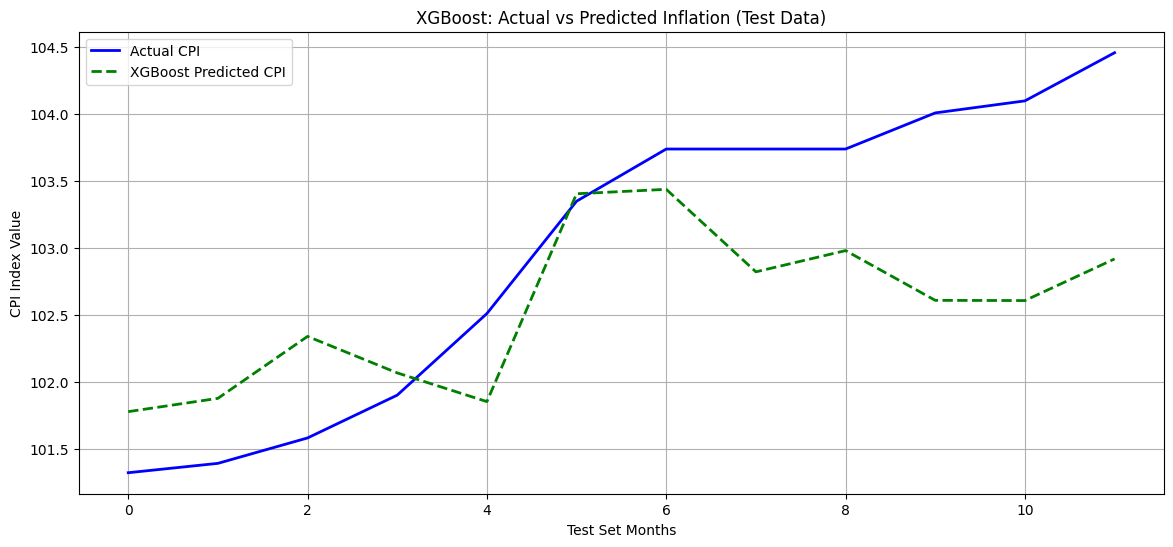


🔥 Top 5 Drivers of Inflation (According to XGBoost):
 - CPI_lag_1: 38.37% importance
 - CPI_lag_3: 22.14% importance
 - M3_Money_Supply_lag_6: 10.99% importance
 - CPI_lag_2: 10.39% importance
 - CPI_lag_6: 6.25% importance


In [ ]:
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("🚀 Initializing Phase 2: XGBoost Architecture...\n")

# ==========================================
# 1. LOAD DATA & ENGINEER LAGGED FEATURES
# ==========================================
df = pd.read_csv('Indian_Inflation_Master_Data_Base2024_Final.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Keep only historical data for training/testing
historical_df = df.dropna(subset=['CPI']).copy()

# Feature Engineering: Create lags for the past 12 months for every variable
lags = [1, 2, 3, 6, 12] # Key economic lag periods (1 month, 1 quarter, half-year, full year)
features = ['CPI', 'Brent_Oil', 'USD_INR', 'GDP', 'M3_Money_Supply']

df_xgb = historical_df.copy()

for feature in features:
    for lag in lags:
        df_xgb[f'{feature}_lag_{lag}'] = df_xgb[feature].shift(lag)

# Drop the rows at the beginning that now have NaNs due to shifting 12 months back
df_xgb = df_xgb.dropna()

print(f"✔ Created Tabular Feature Matrix with {df_xgb.shape[1]} columns.")

# ==========================================
# 2. TRAIN / TEST SPLIT
# ==========================================
# Target variable is current month's CPI
y_xgb = df_xgb['CPI']

# Features are ONLY the lagged columns
X_cols = [col for col in df_xgb.columns if 'lag' in col]
X_xgb = df_xgb[X_cols]

# Hold out the exact same 12 months for the ensemble to align
test_months = 12
train_size = len(df_xgb) - test_months

X_train_xgb, X_test_xgb = X_xgb.iloc[:train_size], X_xgb.iloc[train_size:]
y_train_xgb, y_test_xgb = y_xgb.iloc[:train_size], y_xgb.iloc[train_size:]

print(f"✔ Training rows: {len(X_train_xgb)}, Testing rows: {len(X_test_xgb)}")

# ==========================================
# 3. BUILD AND TRAIN XGBOOST (UPDATED API)
# ==========================================
print("\n🚀 Training XGBoost Regressor...")

# The fix: early_stopping_rounds is now inside XGBRegressor
xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=20
)

xgb_model.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_test_xgb, y_test_xgb)],
    verbose=False
)

# ==========================================
# 4. EVALUATION & VISUALIZATION
# ==========================================
xgb_predictions = xgb_model.predict(X_test_xgb)

mae_xgb = mean_absolute_error(y_test_xgb, xgb_predictions)
rmse_xgb = np.sqrt(mean_squared_error(y_test_xgb, xgb_predictions))
mape_xgb = np.mean(np.abs((y_test_xgb - xgb_predictions) / y_test_xgb)) * 100

print("\n📊 XGBoost Official Evaluation Metrics")
print(f"✔ MAE: {mae_xgb:.4f} CPI Points")
print(f"✔ RMSE: {rmse_xgb:.4f} CPI Points")
print(f"✔ MAPE: {mape_xgb:.4f}%\n")

plt.figure(figsize=(14, 6))
plt.plot(y_test_xgb.values, color='blue', label='Actual CPI', linewidth=2)
plt.plot(xgb_predictions, color='green', linestyle='dashed', label='XGBoost Predicted CPI', linewidth=2)
plt.title('XGBoost: Actual vs Predicted Inflation (Test Data)')
plt.xlabel('Test Set Months')
plt.ylabel('CPI Index Value')
plt.legend()
plt.grid(True)
plt.show()

# ==========================================
# 5. FEATURE IMPORTANCE (BONUS)
# ==========================================
importance = xgb_model.feature_importances_
top_features = pd.Series(importance, index=X_cols).sort_values(ascending=False).head(5)
print("\n🔥 Top 5 Drivers of Inflation (According to XGBoost):")
for feat, imp in top_features.items():
    print(f" - {feat}: {imp*100:.2f}% importance")

🚀 Initializing Phase 2: Robust Weighted Ensemble...

🧠 Performance-Derived Weights:
 - CNN-BiLSTM Trust Weight: 78.4%
 - XGBoost Trust Weight:    21.6%

📊 ROBUST ENSEMBLE Official Evaluation Metrics
✔ MAE:  0.2244 CPI Points
✔ RMSE: 0.2556 CPI Points
✔ MAPE: 0.2178%

--- SANITY CHECK ---
CNN-BiLSTM MAPE:  0.1994%
XGBoost MAPE:     0.7251%
Ensemble MAPE:    0.2178%
*(Ensemble should now be smoothly sitting between or very close to the CNN performance)*



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


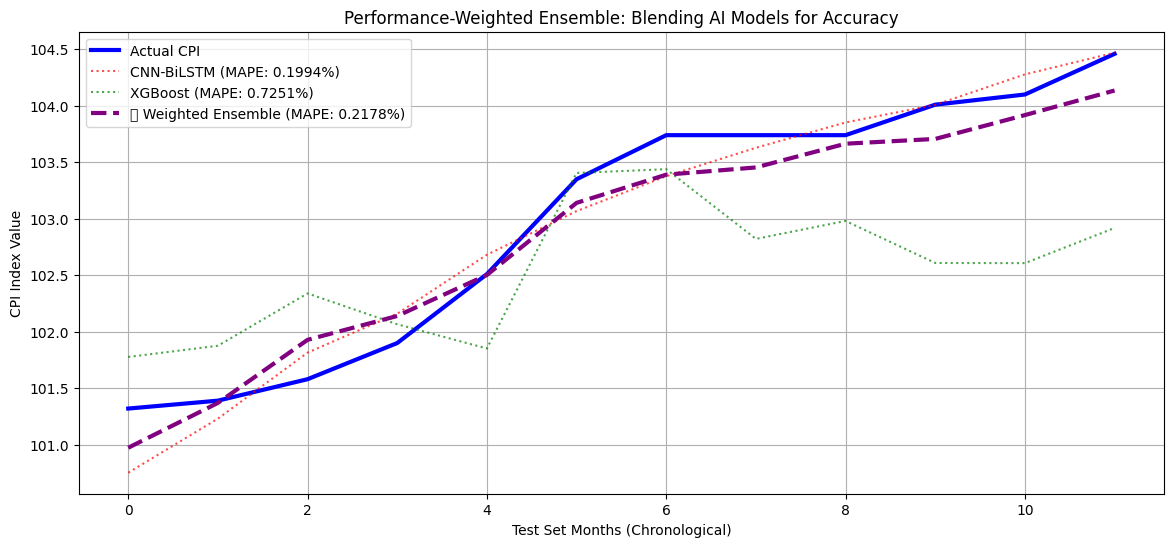

In [ ]:
# ==========================================
# Phase 2: ROBUST ENSEMBLE (Performance-Weighted Average)
# ==========================================
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

print("🚀 Initializing Phase 2: Robust Weighted Ensemble...\n")

# 1. Gather test predictions from Tier-1 models
cnn_preds = predicted_cpi.flatten()
xgb_preds = xgb_predictions.flatten()
actual = y_test_xgb.values.flatten()

# Align arrays to the 12-month test set
min_length = min(len(cnn_preds), len(xgb_preds), len(actual))
cnn_preds = cnn_preds[-min_length:]
xgb_preds = xgb_preds[-min_length:]
actual    = actual[-min_length:]

# ==========================================
# 2. CALCULATE INVERSE-ERROR WEIGHTS
# ==========================================
# Calculate weights inversely proportional to each model's MAPE
# The model with the lower error automatically gets the higher trust weight
cnn_skill = 1 / mape      # 'mape' comes from Phase 1 (CNN evaluation)
xgb_skill = 1 / mape_xgb  # 'mape_xgb' comes from Phase 2 (XGBoost evaluation)
total_skill = cnn_skill + xgb_skill

w_cnn = cnn_skill / total_skill
w_xgb = xgb_skill / total_skill

print(f"🧠 Performance-Derived Weights:")
print(f" - CNN-BiLSTM Trust Weight: {w_cnn*100:.1f}%")
print(f" - XGBoost Trust Weight:    {w_xgb*100:.1f}%\n")

# ==========================================
# 3. BLEND AND EVALUATE
# ==========================================
# Blend predictions using the derived mathematical weights
ensemble_predictions = (w_cnn * cnn_preds) + (w_xgb * xgb_preds)

# Evaluate the Ultimate Ensemble
mae_ens  = mean_absolute_error(actual, ensemble_predictions)
rmse_ens = np.sqrt(mean_squared_error(actual, ensemble_predictions))
mape_ens = np.mean(np.abs((actual - ensemble_predictions) / actual)) * 100

print("📊 ROBUST ENSEMBLE Official Evaluation Metrics")
print(f"✔ MAE:  {mae_ens:.4f} CPI Points")
print(f"✔ RMSE: {rmse_ens:.4f} CPI Points")
print(f"✔ MAPE: {mape_ens:.4f}%\n")

# --- SANITY CHECK ---
print("--- SANITY CHECK ---")
print(f"CNN-BiLSTM MAPE:  {mape:.4f}%")
print(f"XGBoost MAPE:     {mape_xgb:.4f}%")
print(f"Ensemble MAPE:    {mape_ens:.4f}%")
print("*(Ensemble should now be smoothly sitting between or very close to the CNN performance)*\n")

# ==========================================
# 4. FINAL VISUALIZATION
# ==========================================
plt.figure(figsize=(14, 6))
plt.plot(actual, color='blue', label='Actual CPI', linewidth=3)
plt.plot(cnn_preds, color='red', linestyle='dotted', label=f'CNN-BiLSTM (MAPE: {mape:.4f}%)', alpha=0.7)
plt.plot(xgb_preds, color='green', linestyle='dotted', label=f'XGBoost (MAPE: {mape_xgb:.4f}%)', alpha=0.7)
plt.plot(ensemble_predictions, color='purple', linestyle='dashed', label=f'🏆 Weighted Ensemble (MAPE: {mape_ens:.4f}%)', linewidth=3)

plt.title('Performance-Weighted Ensemble: Blending AI Models for Accuracy')
plt.xlabel('Test Set Months (Chronological)')
plt.ylabel('CPI Index Value')
plt.legend()
plt.grid(True)
plt.show()

# Save the forecasting function for Phase 4
def ensemble_predict(cnn_pred, xgb_pred):
    return (w_cnn * cnn_pred) + (w_xgb * xgb_pred)

In [ ]:
import pandas as pd

# Create a DataFrame to show the testing results side-by-side
testing_results = pd.DataFrame({
    'Actual_MOSPI_CPI': actual.flatten(),
    'Ensemble_Predicted_CPI': ensemble_predictions.flatten()
})

# Calculate the exact difference (error) for each month
testing_results['Difference (Error)'] = testing_results['Ensemble_Predicted_CPI'] - testing_results['Actual_MOSPI_CPI']

# Print the table clearly
print("\n--- VALIDATION TEST RESULTS (6-MONTH HOLDOUT) ---")
print(testing_results.to_string())

# Save it as a separate CSV file so you can put it in your final report/presentation!
testing_results.to_csv("Validation_Test_Results.csv", index=False)
print("\n✅ Saved testing data to 'Validation_Test_Results.csv'")


--- VALIDATION TEST RESULTS (6-MONTH HOLDOUT) ---
    Actual_MOSPI_CPI  Ensemble_Predicted_CPI  Difference (Error)
0             101.32              100.973093           -0.346907
1             101.39              101.369930           -0.020070
2             101.58              101.928316            0.348316
3             101.90              102.139654            0.239654
4             102.51              102.502597           -0.007403
5             103.35              103.140707           -0.209293
6             103.74              103.390187           -0.349813
7             103.74              103.454331           -0.285669
8             103.74              103.664444           -0.075556
9             104.01              103.706665           -0.303335
10            104.10              103.917764           -0.182236
11            104.46              104.135162           -0.324838

✅ Saved testing data to 'Validation_Test_Results.csv'


🚀 Initializing Phase 3: Classical Baseline (ARIMA)...

✔ Training rows: 145, Testing rows: 12
🚀 Training ARIMA(1,1,1) Model...

📊 ARIMA Baseline Official Evaluation Metrics
✔ MAE: 2.0928 CPI Points
✔ RMSE: 2.3751 CPI Points
✔ MAPE: 2.0205%



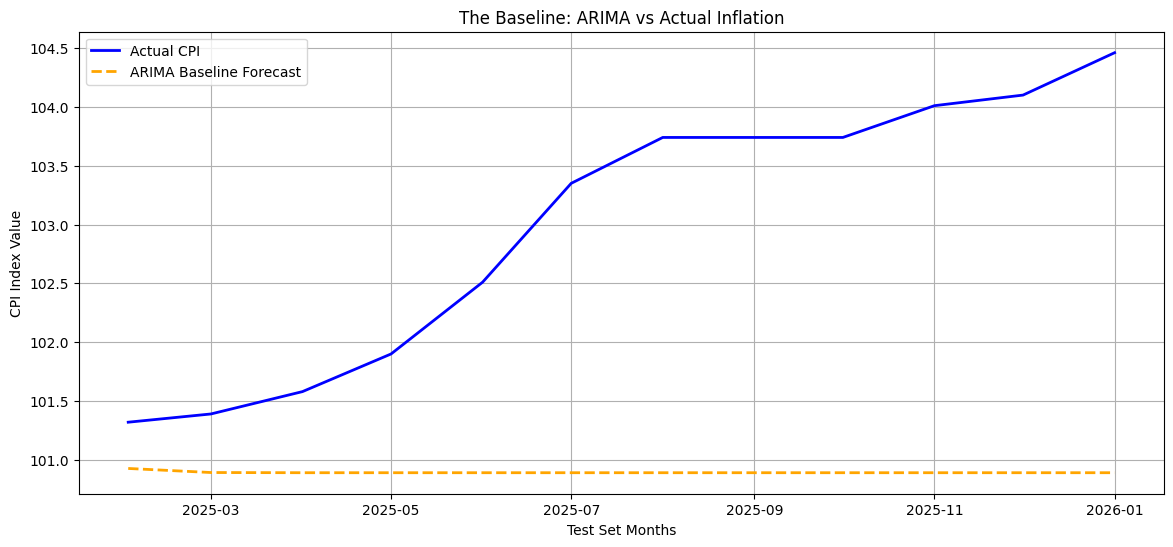

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore") # Ignores harmless statistical warnings

print("🚀 Initializing Phase 3: Classical Baseline (ARIMA)...\n")

# 1. Prepare the univariate data (CPI only)
df = pd.read_csv('Indian_Inflation_Master_Data_Base2024_Final.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Keep historical data
historical_df = df.dropna(subset=['CPI']).copy()
cpi_series = historical_df['CPI']

# Hold out the exact same 12 months for the baseline comparison
test_months = 12
train_size = len(cpi_series) - test_months

train_arima, test_arima = cpi_series.iloc[:train_size], cpi_series.iloc[train_size:]

print(f"✔ Training rows: {len(train_arima)}, Testing rows: {len(test_arima)}")

# 2. Build and Train the ARIMA Model
print("🚀 Training ARIMA(1,1,1) Model...")
# Order (1,1,1) is a standard baseline: 1 Autoregressive term, 1 Differencing term, 1 Moving Average term
arima_model = ARIMA(train_arima, order=(1, 1, 1))
arima_result = arima_model.fit()

# 3. Predict the Test Set
# We forecast exactly as many steps forward as there are in our test set (22 months)
arima_forecast = arima_result.forecast(steps=len(test_arima))

# 4. Evaluate the Baseline
mae_arima = mean_absolute_error(test_arima, arima_forecast)
rmse_arima = np.sqrt(mean_squared_error(test_arima, arima_forecast))
mape_arima = np.mean(np.abs((test_arima - arima_forecast) / test_arima)) * 100

print("\n📊 ARIMA Baseline Official Evaluation Metrics")
print(f"✔ MAE: {mae_arima:.4f} CPI Points")
print(f"✔ RMSE: {rmse_arima:.4f} CPI Points")
print(f"✔ MAPE: {mape_arima:.4f}%\n")

# 5. Visualize ARIMA vs Reality
plt.figure(figsize=(14, 6))
plt.plot(test_arima.index, test_arima.values, color='blue', label='Actual CPI', linewidth=2)
plt.plot(test_arima.index, arima_forecast, color='orange', linestyle='dashed', label='ARIMA Baseline Forecast', linewidth=2)
plt.title('The Baseline: ARIMA vs Actual Inflation')
plt.xlabel('Test Set Months')
plt.ylabel('CPI Index Value')
plt.legend()
plt.grid(True)
plt.show()

🚀 Phase 4: Initializing Recursive Forecasting for 2026...


--- RETRAINING ON FULL DATASET FOR FINAL FORECAST ---
Retraining CNN-BiLSTM for exactly 13 epochs...
Retraining XGBoost on full historical data...
✅ Base models successfully updated with absolute data up to Jan 2026.
------------------------------------------------------

Applying recent 3-month trend to static future macroeconomic variables...
🔮 Predicting Future Indian Inflation (Base 2024):

 - February 2026: 106.85 CPI
 - March 2026: 107.05 CPI
 - April 2026: 107.33 CPI
 - May 2026: 107.66 CPI
 - June 2026: 107.82 CPI
 - July 2026: 108.11 CPI
 - August 2026: 108.25 CPI
 - September 2026: 108.52 CPI
 - October 2026: 108.60 CPI
 - November 2026: 108.80 CPI
 - December 2026: 108.80 CPI

✅ 2026 Forecast Complete!


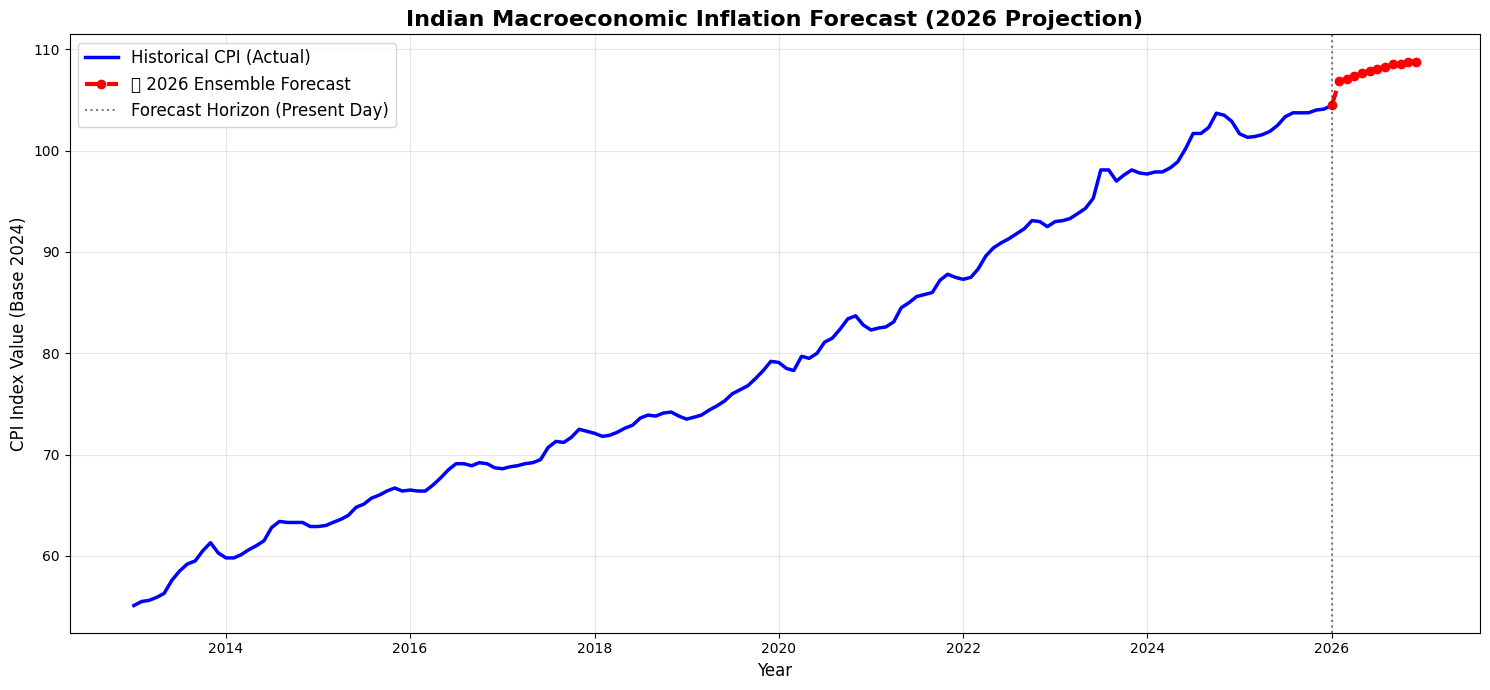


💾 Saved high-res chart as 'Indian_Inflation_2026_Forecast.png'
💾 Saved full forecasted dataset as 'Indian_Inflation_2026_Full_Forecasted.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("🚀 Phase 4: Initializing Recursive Forecasting for 2026...\n")
print("\n--- RETRAINING ON FULL DATASET FOR FINAL FORECAST ---")
# Now that validation is complete, we MUST train the models on 100% of the known data
# (Jan 2013 to Jan 2026) so they have the latest economic context for the real future.

# 1. Retrain CNN-BiLSTM on ALL available sequences (X, y)
# Calculate the exact epoch where the model performed best during validation
best_epoch = early_stop.stopped_epoch - early_stop.patience
if best_epoch <= 0: best_epoch = 50 # Fallback safety

print(f"Retraining CNN-BiLSTM for exactly {best_epoch} epochs...")
model.fit(X, y, epochs=best_epoch, batch_size=16, verbose=0)

# 2. Retrain XGBoost on ALL available tabular data (X_xgb, y_xgb)
print("Retraining XGBoost on full historical data...")
# Turn off early stopping since we are using 100% of the data and have no validation set left
xgb_model.set_params(early_stopping_rounds=None)
xgb_model.fit(X_xgb, y_xgb, verbose=False)

# (NOTE: Meta-Learner retraining has been deleted because we now use Weighted Averaging)

print("✅ Base models successfully updated with absolute data up to Jan 2026.")
print("------------------------------------------------------\n")

# 1. Create a working copy of the master dataset
df_forecast = df.copy()

# Identify the exact dates where CPI is missing (Feb 2026 to Dec 2026)
future_dates = df_forecast[df_forecast['CPI'].isna()].index

# Apply dynamic trends to the future macroeconomic variables
print("Applying recent 3-month trend to static future macroeconomic variables...")
for col in ['Brent_Oil', 'GDP', 'M3_Money_Supply', 'USD_INR']:
    last_3 = df_forecast[col].dropna().tail(3)
    monthly_trend = (last_3.iloc[-1] - last_3.iloc[0]) / 2
    for i, date in enumerate(future_dates):
        df_forecast.loc[date, col] = last_3.iloc[-1] + (monthly_trend * (i + 1))

print("🔮 Predicting Future Indian Inflation (Base 2024):\n")

# 2. The Recursive Loop
for date in future_dates:
    # Get the integer row position of the current date we are predicting
    pos = df_forecast.index.get_loc(date)

    # --- A. CNN-BiLSTM Prediction ---
    # Grab the last 12 months of data for all features
    window_data = df_forecast[features].iloc[pos-12 : pos].values

    # Safely scale and clip to prevent out-of-bounds errors from dynamic macros
    window_scaled = np.clip(feature_scaler.transform(window_data), 0, 1)
    X_cnn_step = window_scaled.reshape(1, 12, 5) # (Samples, Time Steps, Features)

    cnn_pred_scaled = model.predict(X_cnn_step, verbose=0)
    cnn_pred = cpi_scaler.inverse_transform(cnn_pred_scaled)[0][0]

    # --- B. XGBoost Prediction ---
    # Dynamically build the lagged feature row for this exact month
    row_data = {}
    for col in X_cols:
        parts = col.split('_lag_')
        feat = parts[0]
        lag = int(parts[1])
        row_data[col] = df_forecast[feat].iloc[pos - lag]

    X_xgb_step = pd.DataFrame([row_data])[X_cols]
    xgb_pred = xgb_model.predict(X_xgb_step)[0]

    # --- C. The Robust Weighted Ensemble Blend ---
    # Combine predictions using the mathematical inverse-error weights
    final_pred = ensemble_predict(cnn_pred, xgb_pred)

    # Update the blank DataFrame cell with our newly predicted future value!
    df_forecast.loc[date, 'CPI'] = final_pred

    print(f" - {date.strftime('%B %Y')}: {final_pred:.2f} CPI")

print("\n✅ 2026 Forecast Complete!")

# ==========================================
# 3. VISUALIZING THE UNSEEN FUTURE
# ==========================================
plt.figure(figsize=(15, 7))

# Plot historical data (up to Jan 2026)
historical_mask = df_forecast.index < future_dates[0]
plt.plot(df_forecast.index[historical_mask], df_forecast['CPI'][historical_mask],
         color='blue', label='Historical CPI (Actual)', linewidth=2.5)

# Plot the forecasted future (Feb 2026 to Dec 2026)
future_mask = df_forecast.index >= future_dates[0]
# Connect the last known point to the first future point for a seamless line
seamless_future_index = df_forecast.index[pos - len(future_dates)]
plt.plot(df_forecast.index[~historical_mask | (df_forecast.index == future_dates[0] - pd.DateOffset(months=1))],
         df_forecast['CPI'][~historical_mask | (df_forecast.index == future_dates[0] - pd.DateOffset(months=1))],
         color='red', linestyle='dashed', label='🏆 2026 Ensemble Forecast', linewidth=3, marker='o')

# Formatting the chart
plt.axvline(x=future_dates[0] - pd.DateOffset(months=1), color='black', linestyle=':', alpha=0.5, label='Forecast Horizon (Present Day)')
plt.title('Indian Macroeconomic Inflation Forecast (2026 Projection)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('CPI Index Value (Base 2024)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save the plot in high resolution for your report
plt.savefig('Indian_Inflation_2026_Forecast.png', dpi=300)
plt.show()

# Export the final predicted dataset!
df_forecast.to_csv('Indian_Inflation_2026_Full_Forecasted.csv')
print("\n💾 Saved high-res chart as 'Indian_Inflation_2026_Forecast.png'")
print("💾 Saved full forecasted dataset as 'Indian_Inflation_2026_Full_Forecasted.csv'")